#**Churn Prediction Project**

####Phase 1: Data Preparation

####Phase 2: Algorithm Selection

####Phase 3: Model Training & Hyperparameter Sensitivity




##**Cell 1 — Imports and Load Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/churn_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (3000, 24)


,customer_id,age,region,subscription_type,device_type,contract_type,payment_method,satisfaction_score,tenure_months,monthly_spend,sessions_per_week,avg_session_minutes,weekly_minutes,usage_score_proxy,support_tickets_90d,payment_delays_6m,last_login_days_ago,estimated_income,usage_variability,engagement_score,spend_per_session,promo_opt_in,auto_renew,churn
0,1802,43,West,Basic,Desktop,Annual,Card,4,12,31.29,5.45,25.33,141.32,125.04,1.0,0,3.16,71992.25,9.28,66.35,5.74,Yes,1,0
1,1191,56,Central,Premium,Tablet,Monthly,Digital Wallet,3,20,94.87,4.02,17.73,71.07,72.07,1.0,1,1.32,76491.36,5.80,64.48,23.60,No,1,0
2,1818,49,South,Standard,Mobile,Quarterly,Card,3,14,52.79,3.28,26.70,97.86,78.26,3.0,1,3.51,50142.54,5.85,65.29,16.08,Yes,1,0
3,252,42,West,Premium,Mobile,Monthly,Card,4,43,95.69,3.92,18.71,81.94,56.04,0.0,1,0.10,46343.44,5.98,74.45,24.38,No,1,0
4,2506,49,Central,Basic,Mobile,Quarterly,Digital Wallet,3,19,21.77,4.34,19.14,83.87,50.05,1.0,0,6.89,45548.74,4.22,70.99,5.02,Yes,1,0


##**Cell 2 — Phase 1: Basic EDA**

In [ ]:
print(df.info())
print("\nChurn rate:", round(df["churn"].mean(), 4))
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          3000 non-null   int64  
 1   age                  3000 non-null   int64  
 2   region               3000 non-null   object 
 3   subscription_type    3000 non-null   object 
 4   device_type          3000 non-null   object 
 5   contract_type        3000 non-null   object 
 6   payment_method       3000 non-null   object 
 7   satisfaction_score   3000 non-null   int64  
 8   tenure_months        3000 non-null   int64  
 9   monthly_spend        2908 non-null   float64
 10  sessions_per_week    3000 non-null   float64
 11  avg_session_minutes  2877 non-null   float64
 12  weekly_minutes       3000 non-null   float64
 13  usage_score_proxy    3000 non-null   float64
 14  support_tickets_90d  2940 non-null   float64
 15  payment_delays_6m    3000 non-null   i

,0
engagement_score,279
avg_session_minutes,123
estimated_income,103
monthly_spend,92
last_login_days_ago,70
support_tickets_90d,60
customer_id,0
age,0
satisfaction_score,0
payment_method,0


#**Cell 3 — Missing Values**

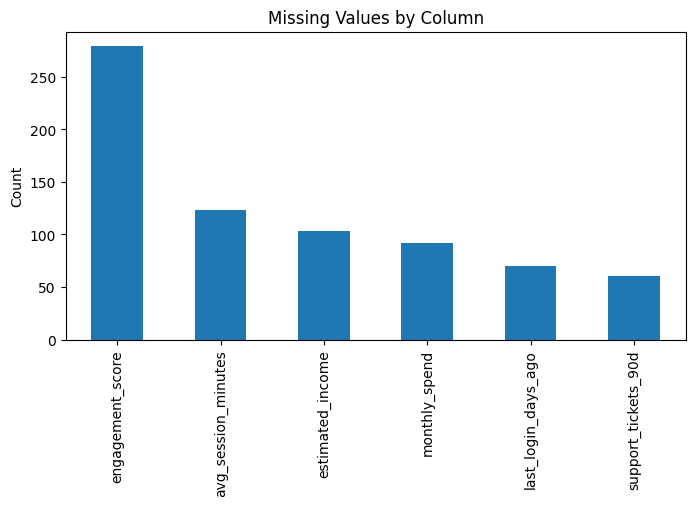

,Missing Count,Missing Percent
engagement_score,279,9.30
avg_session_minutes,123,4.10
estimated_income,103,3.43
monthly_spend,92,3.07
last_login_days_ago,70,2.33
support_tickets_90d,60,2.00


In [ ]:
missing_count = df.isna().sum()
missing_count = missing_count[missing_count > 0].sort_values(ascending=False)

missing_percent = (df.isna().mean() * 100)
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

missing = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percent": missing_percent.round(2)
})

plt.figure(figsize=(8, 4))
missing_count.plot(kind="bar")
plt.title("Missing Values by Column")
plt.ylabel("Count")
plt.show()

missing

##**Cell 4 — Check Whether Missingness Looks Random**

In [ ]:
missing_results = []

for col in missing.index:
    temp = df[[col, "churn"]].copy()
    temp["is_missing"] = temp[col].isna().astype(int)

    churn_rates = temp.groupby("is_missing")["churn"].mean()
    table = pd.crosstab(temp["is_missing"], temp["churn"])
    chi2, p, _, _ = chi2_contingency(table)

    missing_results.append([
        col,
        round(churn_rates.get(0, 0), 4),
        round(churn_rates.get(1, 0), 4),
        p
    ])

missing_df = pd.DataFrame(
    missing_results,
    columns=["Column", "Churn Rate (Not Missing)", "Churn Rate (Missing)", "p_value"]
).sort_values("p_value")

missing_df

,Column,Churn Rate (Not Missing),Churn Rate (Missing),p_value
0,engagement_score,0.3572,0.4086,0.101977
5,support_tickets_90d,0.3605,0.4333,0.305013
3,monthly_spend,0.3631,0.3261,0.536674
1,avg_session_minutes,0.3632,0.3333,0.562082
4,last_login_days_ago,0.3628,0.3286,0.643326
2,estimated_income,0.3624,0.3495,0.869737


##**Cell 5 — Distributions and Outliers**

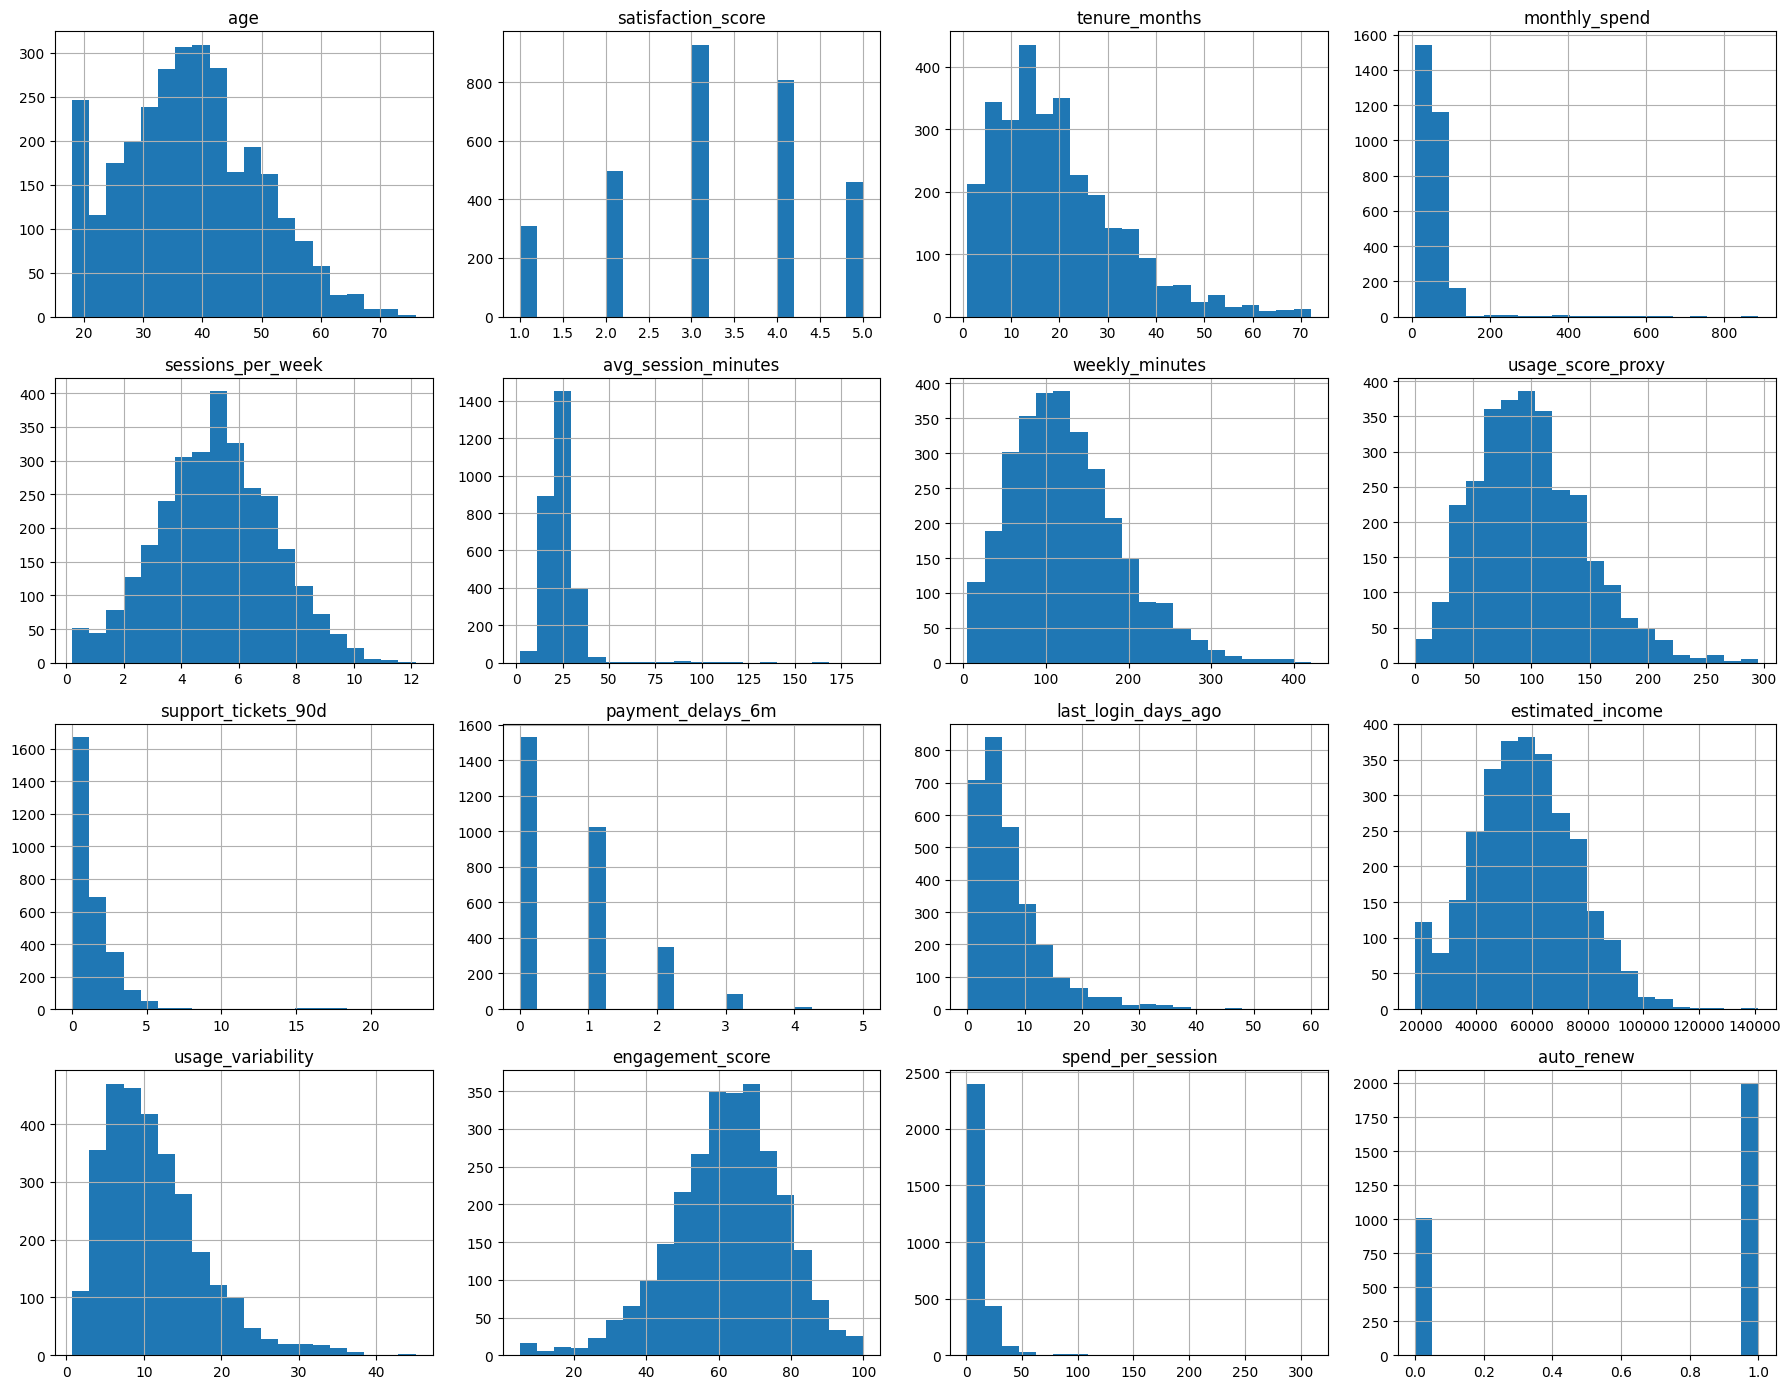

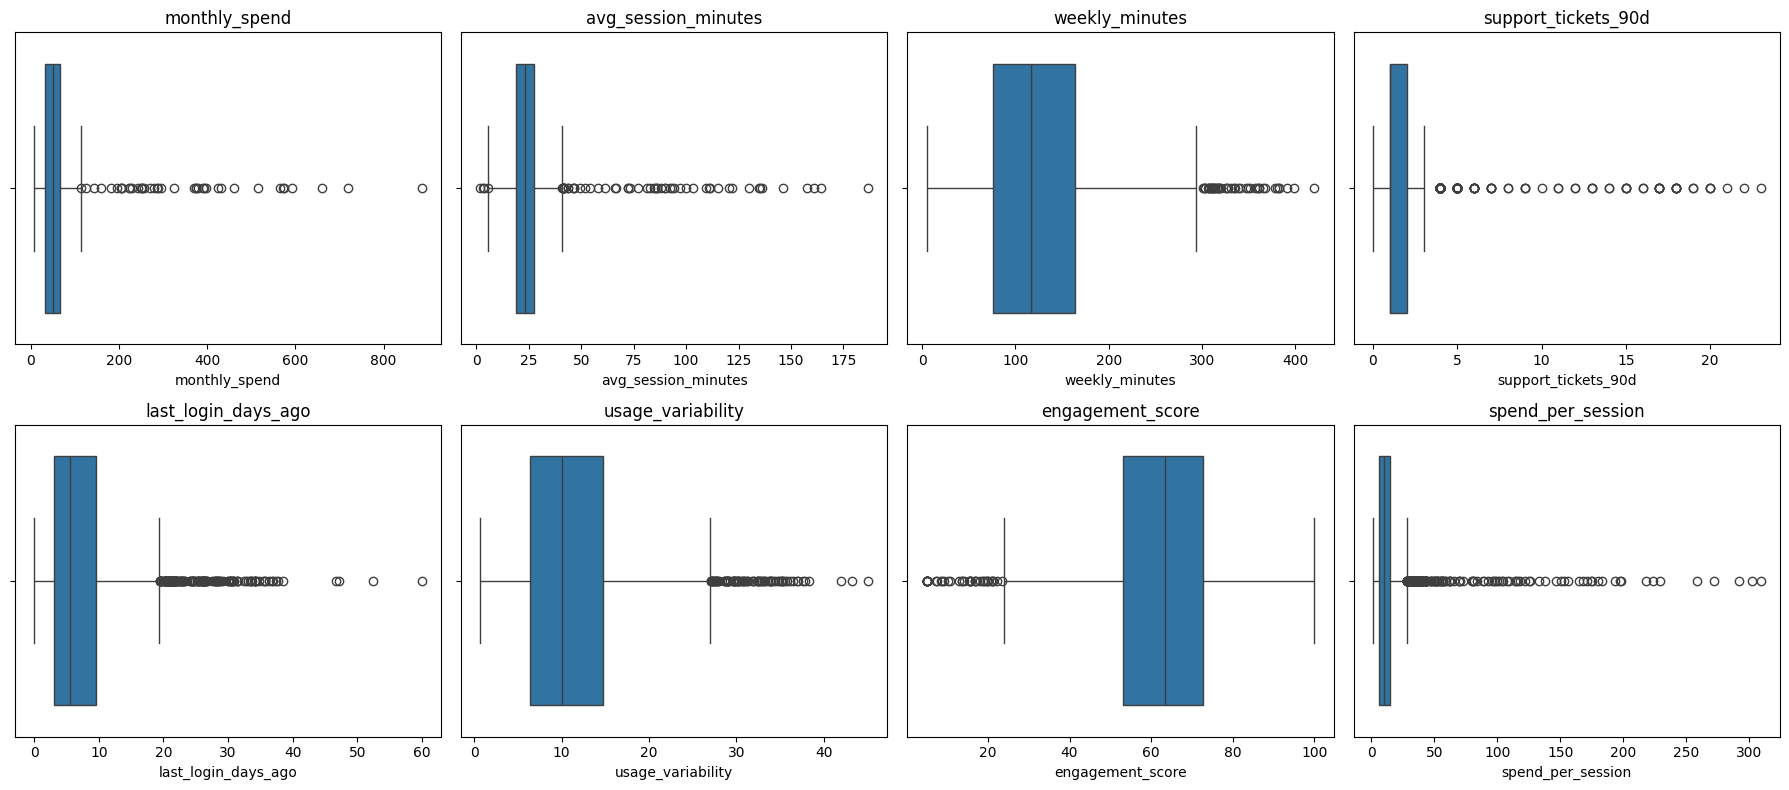

In [ ]:
num_cols = [c for c in df.select_dtypes(include="number").columns if c not in ["customer_id", "churn"]]

df[num_cols].hist(bins=20, figsize=(18, 14))
plt.tight_layout()
plt.show()

box_cols = [
    "monthly_spend", "avg_session_minutes", "weekly_minutes",
    "support_tickets_90d", "last_login_days_ago",
    "usage_variability", "engagement_score", "spend_per_session"
]

box_cols = [c for c in box_cols if c in df.columns]

plt.figure(figsize=(18, 8))
for i, col in enumerate(box_cols, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
outlier_rows = []

for col in num_cols:
    temp = df[col].dropna()
    q1 = temp.quantile(0.25)
    q3 = temp.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((temp < lower) | (temp > upper)).sum()

    outlier_rows.append([col, int(count), round(100 * count / len(temp), 2)])

outlier_df = pd.DataFrame(outlier_rows, columns=["Feature", "Outlier Count", "Outlier %"]).sort_values("Outlier Count", ascending=False)
outlier_df

,Feature,Outlier Count,Outlier %
8,support_tickets_90d,225,7.65
14,spend_per_session,215,7.17
10,last_login_days_ago,159,5.43
9,payment_delays_6m,101,3.37
2,tenure_months,100,3.33
12,usage_variability,83,2.77
5,avg_session_minutes,58,2.02
6,weekly_minutes,46,1.53
13,engagement_score,43,1.58
3,monthly_spend,41,1.41


##**Cell 6 — Correlation, Covariance, and Chi-Square**

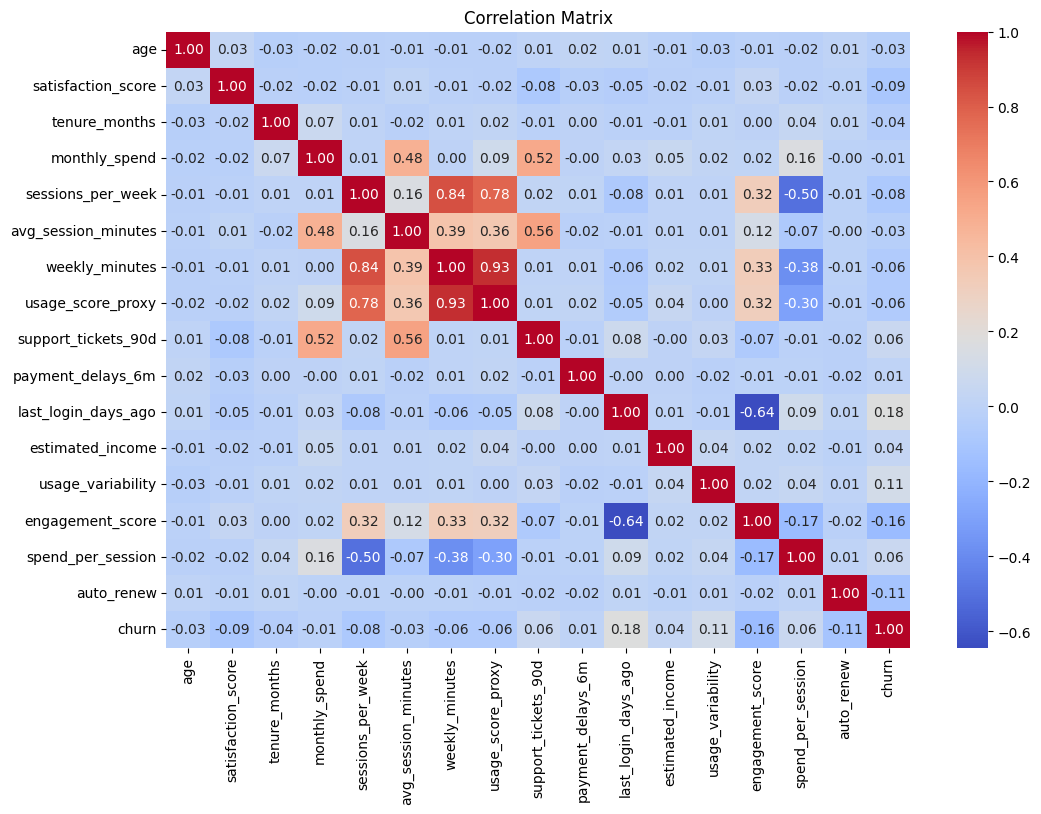

In [ ]:
num_cols = df.select_dtypes(include="number").columns.tolist()

if "customer_id" in num_cols:
    num_cols.remove("customer_id")

numeric_df = df[num_cols].copy()
numeric_df = numeric_df.fillna(numeric_df.mean())

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

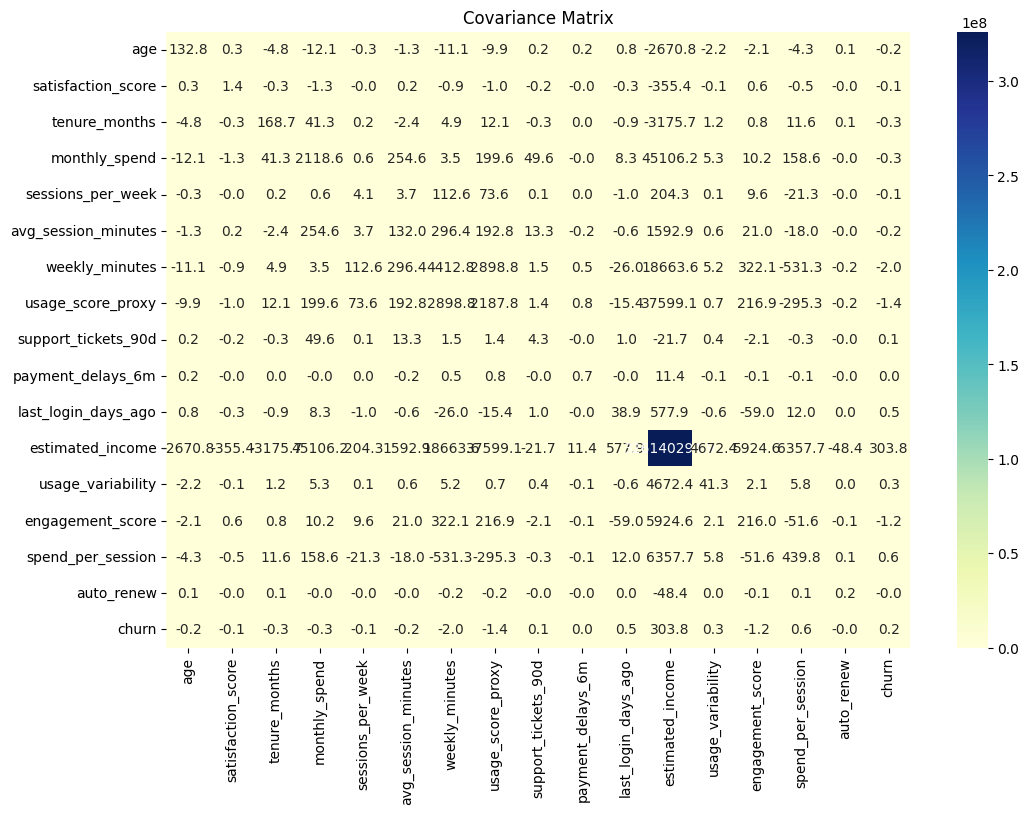

In [ ]:
cov_matrix = numeric_df.cov()



plt.figure(figsize=(12, 8))
sns.heatmap(cov_matrix, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title("Covariance Matrix")
plt.show()

In [ ]:
cat_cols = df.select_dtypes(include="object").columns.tolist()

chi_results = []

for col in cat_cols:
    table = pd.crosstab(df[col], df["churn"])
    chi2, p, dof, expected = chi2_contingency(table)

    chi_results.append({
        "Feature": col,
        "Chi-Square": round(chi2, 4),
        "P-value": round(p, 6)
    })

chi_results_df = pd.DataFrame(chi_results).sort_values("P-value")

chi_results_df

,Feature,Chi-Square,P-value
3,contract_type,170.2139,0.000000
0,region,15.5281,0.003722
5,promo_opt_in,2.1482,0.142735
4,payment_method,1.8319,0.400140
1,subscription_type,0.9839,0.611419
2,device_type,0.2986,0.861318


##**Cell 7 — Feature Engineering**

In [ ]:
work_df = df.copy()

cycle_map = {"Monthly": 1, "Quarterly": 3, "Annual": 12}
work_df["cycle_months"] = work_df["contract_type"].map(cycle_map)

work_df["is_renewal_time"] = (work_df["tenure_months"] % work_df["cycle_months"] == 0).astype(int)
work_df["inactive_engagement_gap"] = work_df["last_login_days_ago"] / (work_df["engagement_score"] + 1)
work_df["stability_gap"] = work_df["usage_variability"] / (work_df["engagement_score"] + 1)
work_df["support_pressure"] = work_df["support_tickets_90d"] / (work_df["sessions_per_week"] + 1)

model_df = work_df.drop(columns=["customer_id", "weekly_minutes", "usage_score_proxy", "support_tickets_90d", "cycle_months"])
model_df.head()

,age,region,subscription_type,device_type,contract_type,payment_method,satisfaction_score,tenure_months,monthly_spend,sessions_per_week,avg_session_minutes,payment_delays_6m,last_login_days_ago,estimated_income,usage_variability,engagement_score,spend_per_session,promo_opt_in,auto_renew,churn,is_renewal_time,inactive_engagement_gap,stability_gap,support_pressure
0,43,West,Basic,Desktop,Annual,Card,4,12,31.29,5.45,25.33,0,3.16,71992.25,9.28,66.35,5.74,Yes,1,0,1,0.046919,0.137788,0.155039
1,56,Central,Premium,Tablet,Monthly,Digital Wallet,3,20,94.87,4.02,17.73,1,1.32,76491.36,5.80,64.48,23.60,No,1,0,1,0.020159,0.088577,0.199203
2,49,South,Standard,Mobile,Quarterly,Card,3,14,52.79,3.28,26.70,1,3.51,50142.54,5.85,65.29,16.08,Yes,1,0,0,0.052949,0.088249,0.700935
3,42,West,Premium,Mobile,Monthly,Card,4,43,95.69,3.92,18.71,1,0.10,46343.44,5.98,74.45,24.38,No,1,0,1,0.001325,0.079258,0.000000
4,49,Central,Basic,Mobile,Quarterly,Digital Wallet,3,19,21.77,4.34,19.14,0,6.89,45548.74,4.22,70.99,5.02,Yes,1,0,0,0.095708,0.058619,0.187266


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

work_df = df.copy()

work_df["cycle_months"] = work_df["contract_type"].map({
    "Monthly": 1,
    "Quarterly": 3,
    "Annual": 12
})

work_df["is_renewal_time"] = (work_df["tenure_months"] % work_df["cycle_months"] == 0).astype(int)
work_df["inactive_engagement_gap"] = work_df["last_login_days_ago"] / (work_df["engagement_score"] + 1)
work_df["stability_gap"] = work_df["usage_variability"] / (work_df["engagement_score"] + 1)
work_df["support_pressure"] = work_df["support_tickets_90d"] / (work_df["sessions_per_week"] + 1)

features = [
    "is_renewal_time",
    "inactive_engagement_gap",
    "stability_gap",
    "support_pressure",
    "weekly_minutes",
    "usage_score_proxy",
    "support_tickets_90d",
    "cycle_months"
]

results = []

for col in features:
    temp = work_df[[col, "churn"]].dropna().copy()

    if col in ["is_renewal_time", "cycle_months"]:
        temp["group"] = temp[col].astype(str)
    else:
        temp["group"] = pd.qcut(temp[col], 3, labels=["Low", "Medium", "High"], duplicates="drop")

    churn_rates = temp.groupby("group", observed=False)["churn"].mean().round(4)
    max_rate = churn_rates.max()
    min_rate = churn_rates.min()

    results.append({
        "Feature": col,
        "Groups": churn_rates.to_dict(),
        "Churn Gap": round(max_rate - min_rate, 4),
        "Lift": round(max_rate / min_rate, 2) if min_rate > 0 else None
    })

results_df = pd.DataFrame(results).sort_values("Churn Gap", ascending=False)
display(results_df)

,Feature,Groups,Churn Gap,Lift
7,cycle_months,"{'1': 0.4503, '12': 0.1587, '3': 0.3343}",0.2916,2.84
1,inactive_engagement_gap,"{'Low': 0.2728, 'Medium': 0.3337, 'High': 0.4707}",0.1979,1.73
0,is_renewal_time,"{'0': 0.2365, '1': 0.4286}",0.1921,1.81
2,stability_gap,"{'Low': 0.2944, 'Medium': 0.3219, 'High': 0.4553}",0.1609,1.55
3,support_pressure,"{'Low': 0.3048, 'Medium': 0.3418, 'High': 0.4351}",0.1303,1.43
6,support_tickets_90d,"{'Low': 0.3244, 'Medium': 0.3835, 'High': 0.4377}",0.1133,1.35
5,usage_score_proxy,"{'Low': 0.4086, 'Medium': 0.3433, 'High': 0.334}",0.0746,1.22
4,weekly_minutes,"{'Low': 0.403, 'Medium': 0.336, 'High': 0.347}",0.0670,1.20


#**Cell 8 — Phase 2: Model Comparison**

In [ ]:
X = model_df.drop(columns=["churn"])
y = model_df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=42)
}

model_results = []

for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    model_results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred, zero_division=0),
        recall_score(y_test, pred, zero_division=0),
        f1_score(y_test, pred, zero_division=0)
    ])

model_results_df = pd.DataFrame(
    model_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1"]
).sort_values("F1", ascending=False).reset_index(drop=True)

model_results_df

,Model,Accuracy,Precision,Recall,F1
0,HistGradientBoosting,0.671667,0.568493,0.382488,0.457300
1,Logistic Regression,0.670000,0.568345,0.364055,0.443820
2,Gradient Boosting,0.668333,0.565217,0.359447,0.439437
3,Extra Trees,0.650000,0.527559,0.308756,0.389535
4,Random Forest,0.653333,0.537190,0.299539,0.384615


##**Cell 9 — Phase 3: Logistic Regression Tuning**

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

c_values = [0.15, 0.16, 0.17, 0.18, 0.19, 0.20, 0.21, 0.22, 0.23, 0.24, 0.25]
thresholds = [0.30, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.40]

results = []

for c in c_values:
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", LogisticRegression(C=c, max_iter=3000, random_state=42))
    ])

    pipe.fit(X_tr, y_tr)
    probs = pipe.predict_proba(X_val)[:, 1]

    for t in thresholds:
        preds = (probs >= t).astype(int)

        results.append({
            "C": c,
            "Threshold": t,
            "Accuracy": accuracy_score(y_val, preds),
            "Precision": precision_score(y_val, preds, zero_division=0),
            "Recall": recall_score(y_val, preds, zero_division=0),
            "F1": f1_score(y_val, preds, zero_division=0)
        })

tuning_df = pd.DataFrame(results).sort_values(
    by=["F1", "Recall", "Precision", "Accuracy"],
    ascending=False
).reset_index(drop=True)

tuning_df.iloc[30:41]

,C,Threshold,Accuracy,Precision,Recall,F1
30,0.25,0.33,0.616667,0.481481,0.747126,0.585586
31,0.15,0.34,0.625000,0.488462,0.729885,0.585253
32,0.16,0.34,0.625000,0.488462,0.729885,0.585253
33,0.15,0.36,0.639583,0.502075,0.695402,0.583133
34,0.17,0.36,0.637500,0.500000,0.695402,0.581731
35,0.24,0.38,0.654167,0.518018,0.660920,0.580808
36,0.25,0.38,0.654167,0.518018,0.660920,0.580808
37,0.16,0.31,0.600000,0.468310,0.764368,0.580786
38,0.16,0.36,0.637500,0.500000,0.689655,0.579710
39,0.22,0.36,0.637500,0.500000,0.689655,0.579710


##**Cell 10 — Best Threshold**

    Threshold        F1
0        0.35  0.586047
1        0.25  0.583826
2        0.30  0.572043
3        0.20  0.571429
4        0.40  0.558511
5        0.45  0.507645
6        0.50  0.443686
7        0.55  0.363636
8        0.60  0.326180
9        0.65  0.255924
10       0.70  0.143590

Best Threshold: 0.35


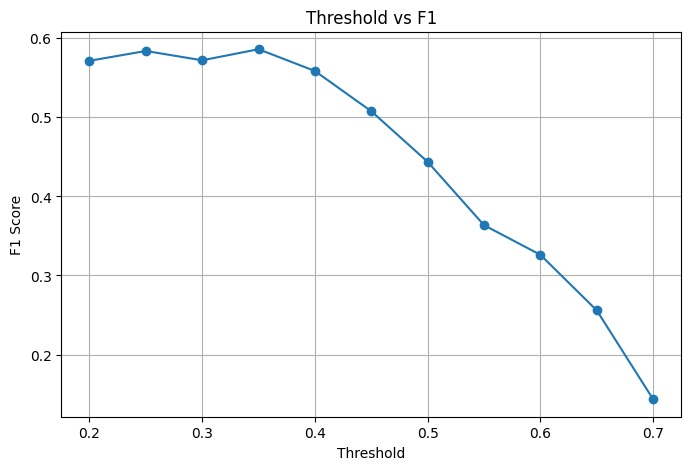

In [ ]:
pipe = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=3000, random_state=42))
])

pipe.fit(X_tr, y_tr)
y_prob = pipe.predict_proba(X_val)[:, 1]

thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]
results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    results.append([t, f1_score(y_val, y_pred, zero_division=0)])

threshold_df = pd.DataFrame(results, columns=["Threshold", "F1"])
threshold_df = threshold_df.sort_values(by="F1", ascending=False).reset_index(drop=True)

print(threshold_df)
print("\nBest Threshold:", threshold_df.loc[0, "Threshold"])

plot_df = threshold_df.sort_values("Threshold")

plt.figure(figsize=(8, 5))
plt.plot(plot_df["Threshold"], plot_df["F1"], marker="o")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold vs F1")
plt.grid(True)
plt.show()

##**Cell 10 — Best C**

        C        F1
0    0.20  0.590698
1    0.30  0.590698
2    0.12  0.590164
3    0.14  0.588785
4    0.16  0.587413
5    0.18  0.587413
6   10.00  0.587413
7    0.09  0.586854
8    0.07  0.586288
9    0.50  0.586047
10   1.00  0.586047
11   5.00  0.586047
12   0.10  0.585480
13   0.01  0.582938
14   0.05  0.582938
15   0.03  0.575472

Best C: 0.2


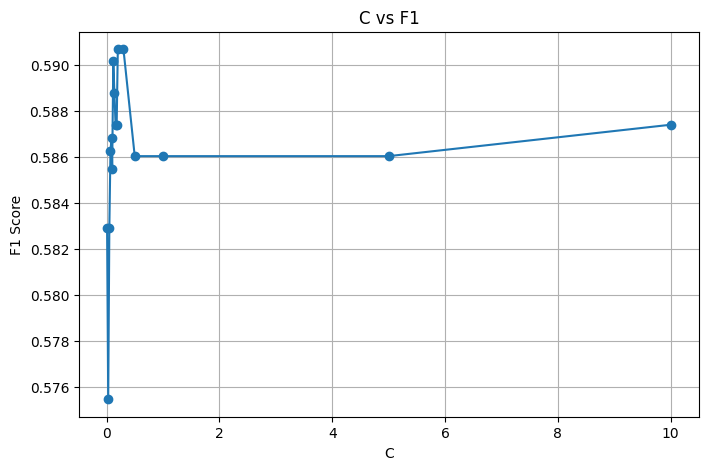

In [ ]:
c_values = [
    0.01, 0.03, 0.05, 0.07, 0.09,
    0.10, 0.12, 0.14, 0.16, 0.18,
    0.20, 0.30, 0.50, 1, 5, 10
]

results = []

for c in c_values:
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", LogisticRegression(C=c, max_iter=3000, random_state=42))
    ])

    pipe.fit(X_tr, y_tr)
    y_prob = pipe.predict_proba(X_val)[:, 1]
    y_pred = (y_prob >= 0.35).astype(int)

    results.append([c, f1_score(y_val, y_pred, zero_division=0)])

c_df = pd.DataFrame(results, columns=["C", "F1"])
c_df = c_df.sort_values(by="F1", ascending=False).reset_index(drop=True)

print(c_df)
print("\nBest C:", c_df.loc[0, "C"])

plot_df = c_df.sort_values("C")

plt.figure(figsize=(8, 5))
plt.plot(plot_df["C"], plot_df["F1"], marker="o")
plt.xlabel("C")
plt.ylabel("F1 Score")
plt.title("C vs F1")
plt.grid(True)
plt.show()